# Sandpile SOC su rete semantica SWOW

Modello **Abelian Sandpile** (Bak-Tang-Wiesenfeld 1987; Dhar 1990) come modello di
*spreading activation* sul lessico mentale. La rete e' costruita dalle norme di
associazione libera **SWOW-EN** (De Deyne et al., 2019). Tutti gli esperimenti —
dagli esempi base alla firma SOC — girano sulla stessa rete SWOW.

Pipeline: rete SWOW -> sottografo BFS (~1500 nodi) con **sink** di confine (nodo di
grado massimo) per la dissipazione -> burn-in (tempo di rilassamento, Dhar 1990) ->
misura delle valanghe in regime stazionario.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, networkx as nx, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import warnings; warnings.filterwarnings("ignore")
plt.rcParams['animation.embed_limit'] = 100
from SpreadPy.Models.sandpile import SandpileSpreading

# --- Rete semantica SWOW (associazioni libere) ---
SWOW_PATH = "../data/SWOW-EN18/strength.SWOW-EN.R123.20180827.csv"
swow = pd.read_csv(SWOW_PATH, sep="\t")
swow = swow[swow["R123"] >= 2]                    # rimuove hapax (1 solo soggetto): rumore
swow = swow.dropna(subset=["cue", "response"])
swow["cue"] = swow["cue"].astype(str).str.lower()
swow["response"] = swow["response"].astype(str).str.lower()
swow = swow[swow["cue"] != swow["response"]]

G_full = nx.Graph()
for c, r in zip(swow["cue"], swow["response"]):
    G_full.add_edge(c, r)
G_full = G_full.subgraph(max(nx.connected_components(G_full), key=len)).copy()
print(f"SWOW backbone: {G_full.number_of_nodes()} nodi, {G_full.number_of_edges()} archi")

# Sottografo BFS dal nodo di grado massimo: riduce gli effetti di taglia finita
# restando entro tempi pratici. Sink = nodo di grado massimo (boundary BTW classico).
def bfs_subgraph(G, seed, target_n):
    nodes = []
    for n in nx.bfs_tree(G, seed).nodes:
        nodes.append(n)
        if len(nodes) >= target_n:
            break
    H = G.subgraph(nodes).copy()
    return H.subgraph(max(nx.connected_components(H), key=len)).copy()

SEED_NODE = max(G_full.nodes, key=lambda n: G_full.degree(n))
G_big = bfs_subgraph(G_full, SEED_NODE, 1500)
SINK = max(G_big.nodes, key=lambda n: G_big.degree(n))
K_big = sum(G_big.degree(n) for n in G_big.nodes if n != SINK)
print(f"Subgrafo SOC: {G_big.number_of_nodes()} nodi  archi={G_big.number_of_edges()}  "
      f"grado medio={2*G_big.number_of_edges()/G_big.number_of_nodes():.2f}")
print(f"Sink = '{SINK}' (deg={G_big.degree(SINK)})   K_tot non-sink = {K_big}")


# --- helper di animazione (riusato negli esempi base) ---
def animate(G, results, pos, title='', special=None, sink=None):
    special = special or {}
    fig, ax = plt.subplots(figsize=(6, 6))
    def update(i):
        ax.clear(); ax.set_axis_off()
        r = results[i]
        cols = []
        for n in G.nodes():
            if n == sink: cols.append('black')
            elif n in r['toppled_nodes']: cols.append('red')
            elif r['status'][n] == 0: cols.append('lightgray')
            elif r['status'][n] < G.degree(n): cols.append('lightblue')
            else: cols.append('orange')
        ec = [special.get(n, 'black') for n in G.nodes()]
        lw = [3 if n in special else 0.5 for n in G.nodes()]
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color='lightgray')
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color=cols, node_size=600,
                               edgecolors=ec, linewidths=lw)
        if r['grain_movements']:
            nx.draw_networkx_edges(G, pos, ax=ax, edgelist=r['grain_movements'],
                                   edge_color='red', width=1.5, arrows=True,
                                   arrowstyle='-|>', arrowsize=13)
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=7,
                                labels={n: f"{n}\n({r['status'][n]})" for n in G.nodes()})
        t = f"{title}  t={r['iteration']}  grani={r['total_grains']}"
        if r['diverged']: t += '  DIVERGED'
        elif r['has_avalanche']: t += f"  size={r['avalanche_size']}"
        ax.set_title(t, fontsize=10)
    ani = animation.FuncAnimation(fig, update, frames=len(results), interval=350, repeat=False)
    plt.close()
    return HTML(ani.to_jshtml())

SWOW backbone: 30128 nodi, 267750 archi


Subgrafo SOC: 1500 nodi  archi=15106  grado medio=20.14
Sink = 'food' (deg=862)   K_tot non-sink = 29350


## 1 — Esempio base: il limite della somma dei gradi

Sistema **chiuso** (nessun sink): i grani entrano e non escono mai. Partendo da
tutto-zero, il totale cresce di 1 a ogni passo finche' supera la **massa massima
stabile** $=\sum_v \deg(v)$ (somma dei gradi). Oltre quel limite nessuna
configurazione stabile esiste e la valanga non termina piu': il sistema **diverge**.
E' la dimostrazione visiva che la SOC richiede dissipazione (un sink, sezioni
successive). Nodi **rossi** = stanno topplando, **arancio** = al limite (altezza =
grado), **azzurro** = parzialmente carichi, **grigi** = vuoti.

In [2]:
# Esempio base CHIUSO: nessun sink. Il sistema e' conservativo -> si riempie da
# tutto-zero e, superata la massa massima stabile (= somma dei gradi), NON puo'
# piu' stabilizzarsi: la valanga non termina -> DIVERGE.
def small_ego(G, center, max_nodes=14):
    nodes = list(nx.ego_graph(G, center, radius=1).nodes())[:max_nodes]
    H = G.subgraph(nodes).copy()
    return H.subgraph(max(nx.connected_components(H), key=len)).copy()

CENTER = sorted(G_big.nodes, key=lambda n: G_big.degree(n))[len(G_big) // 3]
Hdemo = small_ego(G_big, CENTER, max_nodes=14)
sp = SandpileSpreading(Hdemo, sink=None, f=0)        # CHIUSO: nessun sink
print(f"ego di '{CENTER}': {Hdemo.number_of_nodes()} parole   "
      f"somma gradi = max_stable_mass = {sp.max_stable_mass}")

np.random.seed(2)
sp.iteration()
snaps = []
for _ in range(2 * sp.max_stable_mass):              # margine oltre il limite teorico
    r = sp.iteration(node=None)                      # grano su un nodo casuale
    snaps.append(r)
    if r['diverged']:
        print(f"DIVERGE all'iterazione {r['iteration']} (~ somma gradi "
              f"{sp.max_stable_mass}): regime supercritico, serve un sink.")
        break

print(f"timestep mostrati: {len(snaps)}")
animate(Hdemo, snaps, nx.spring_layout(Hdemo, seed=3, k=1.2),
        title=f"ego SWOW '{CENTER}' (chiuso)", special={CENTER: 'green'})

ego di 'blackberry': 13 parole   somma gradi = max_stable_mass = 68
DIVERGE all'iterazione 50 (~ somma gradi 68): regime supercritico, serve un sink.
timestep mostrati: 50


## 2 — Spreading mirato (cue) vs casuale

Confrontiamo la distribuzione delle taglie di valanga quando il grano viene sempre
iniettato su un **concetto-cue** ad alto grado, contro un'iniezione **casuale**. Il
drive mirato su un hub produce valanghe sistematicamente piu' grandi: e' il cuore
dell'effetto fan (sezione 8).

cue (hub) usati: ['meat', 'bread', 'cake', 'cheese', 'butter', 'chocolate']


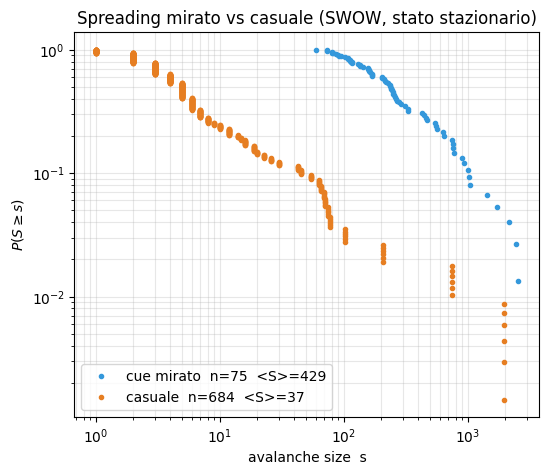

In [3]:
# Sottografo SWOW piu' piccolo (~500 nodi) con sink, per un confronto rapido
G_mid = bfs_subgraph(G_full, SEED_NODE, 500)
SINK_mid = max(G_mid.nodes, key=lambda n: G_mid.degree(n))
K_mid = sum(G_mid.degree(n) for n in G_mid.nodes if n != SINK_mid)

def run_drops(G, sink, K, cue, random_drop, n_steps, seed=0):
    np.random.seed(seed)
    sp = SandpileSpreading(G, sink=sink, f=0)
    sp.iteration()
    for _ in range(K):
        sp.iteration(node=None)                       # burn-in -> stato stazionario
    sizes = []
    for _ in range(n_steps):
        r = sp.iteration(node=None if random_drop else cue)
        if r["diverged"]:
            break
        if r["has_avalanche"]:
            sizes.append(r["avalanche_size"])
    return sizes

cues = sorted([n for n in G_mid.nodes if n != SINK_mid],
              key=lambda n: -G_mid.degree(n))[:6]
print("cue (hub) usati:", cues)
cue_sizes = [s for c in cues for s in run_drops(G_mid, SINK_mid, K_mid, c, False, 500, seed=1)]
rnd_sizes = [s for c in cues for s in run_drops(G_mid, SINK_mid, K_mid, c, True, 500, seed=1)]

def ccdf(x):
    x = np.sort(x)
    return x, 1 - np.arange(len(x)) / len(x)

plt.figure(figsize=(6, 5))
for s, lbl, col in [(cue_sizes, "cue mirato", "#3498db"), (rnd_sizes, "casuale", "#e67e22")]:
    x, y = ccdf(s)
    plt.loglog(x, y, ".", color=col, label=f"{lbl}  n={len(x)}  <S>={np.mean(s):.0f}")
plt.xlabel("avalanche size  s"); plt.ylabel(r"$P(S \geq s)$")
plt.title("Spreading mirato vs casuale (SWOW, stato stazionario)")
plt.legend(); plt.grid(True, which="both", alpha=0.3); plt.show()

## 3 — Firma SOC: power law delle valanghe e dissipazione

Il sandpile BTW e' il prototipo della **Self-Organised Criticality** (Bak, Tang &
Wiesenfeld 1987; Dhar 1990). Firme attese:

1. **Power law delle valanghe**: nel regime critico $P(S \geq s) \propto s^{-(\alpha-1)}$
   con $\alpha \approx 1.5\text{--}2.5$ (Clauset, Shalizi & Newman 2009; libreria
   `powerlaw`, Alstott et al. 2014). Per ridurre gli effetti di taglia finita lavoriamo
   sul sottografo SWOW da ~1500 nodi.
2. **Stato stazionario e dissipazione**: per un vero regime SOC il sistema deve
   dissipare. Usiamo il **nodo di grado massimo come sink** (boundary BTW) per il
   regime critico $f=0$, e confrontiamo con $f$ crescente (dissipazione bulk): $f$
   taglia la coda della power law in modo controllato -> transizione critico ->
   subcritico (Tang & Bak 1988; Manna 1991).

In [4]:
import powerlaw

def run_stationary(G_net, sink, f, n_burn, n_meas, seed=0):
    """Sandpile stazionario con sink. Burn-in (Dhar 1990) poi misura n_meas iter.
    Ritorna (sizes, has_aval, rhos)."""
    np.random.seed(seed)
    sp = SandpileSpreading(G_net, sink=sink, f=f)
    sp.iteration()
    for _ in range(n_burn):
        sp.iteration(node=None)
    sizes, has_aval, rhos = [], [], []
    Nns = len(sp.non_sink_nodes)
    for _ in range(n_meas):
        r = sp.iteration(node=None)
        if r["diverged"]:
            break
        rhos.append(r["total_grains"] / Nns)
        has_aval.append(int(r["has_avalanche"]))
        if r["has_avalanche"]:
            sizes.append(r["avalanche_size"])
    return np.array(sizes), np.array(has_aval), np.array(rhos)

print("Simulazioni stazionarie (burn-in=K, misura=K) ...")
res = {}
for f in [0.0, 0.02, 0.05, 0.10, 0.20, 0.40]:
    s, h, r = run_stationary(G_big, SINK, f=f, n_burn=K_big, n_meas=K_big, seed=42)
    res[f] = {"sizes": s, "has_aval": h, "rhos": r}
    print(f"  f={f:.2f}:  valanghe={len(s):>5d}   <S>={s.mean():7.2f}   "
          f"max(S)={int(s.max()) if len(s) else 0:>6d}   "
          f"rho*={r.mean():.3f}   P(top)={h.mean():.3f}")

Simulazioni stazionarie (burn-in=K, misura=K) ...


  f=0.00:  valanghe= 3245   <S>= 327.65   max(S)= 27178   rho*=11.115   P(top)=0.111


  f=0.02:  valanghe= 3201   <S>= 196.58   max(S)= 24929   rho*=10.983   P(top)=0.109


  f=0.05:  valanghe= 3143   <S>= 120.70   max(S)= 11193   rho*=10.879   P(top)=0.107


  f=0.10:  valanghe= 3096   <S>=  76.15   max(S)=  5960   rho*=10.770   P(top)=0.105


  f=0.20:  valanghe= 3109   <S>=  42.73   max(S)=  3492   rho*=10.675   P(top)=0.106


  f=0.40:  valanghe= 3097   <S>=  22.73   max(S)=  1240   rho*=10.435   P(top)=0.106


Fit power law (f=0): alpha=1.556  x_min=19.0  LR vs exp=19.13  p=1.36e-81
  power_law vs lognormal           : R=-1.52 p=0.13 -> indistinguibili


  power_law vs truncated_power_law : R=-4.92 p=8.6e-06 -> truncated_power_law preferito
Cutoff coda (S al 95-esimo percentile) per f:
  f=0.00:  <S>= 327.6   S95=   577   max=27178
  f=0.02:  <S>= 196.6   S95=   475   max=24929
  f=0.05:  <S>= 120.7   S95=   350   max=11193
  f=0.10:  <S>=  76.1   S95=   289   max=5960
  f=0.20:  <S>=  42.7   S95=   180   max=3492
  f=0.40:  <S>=  22.7   S95=    94   max=1240


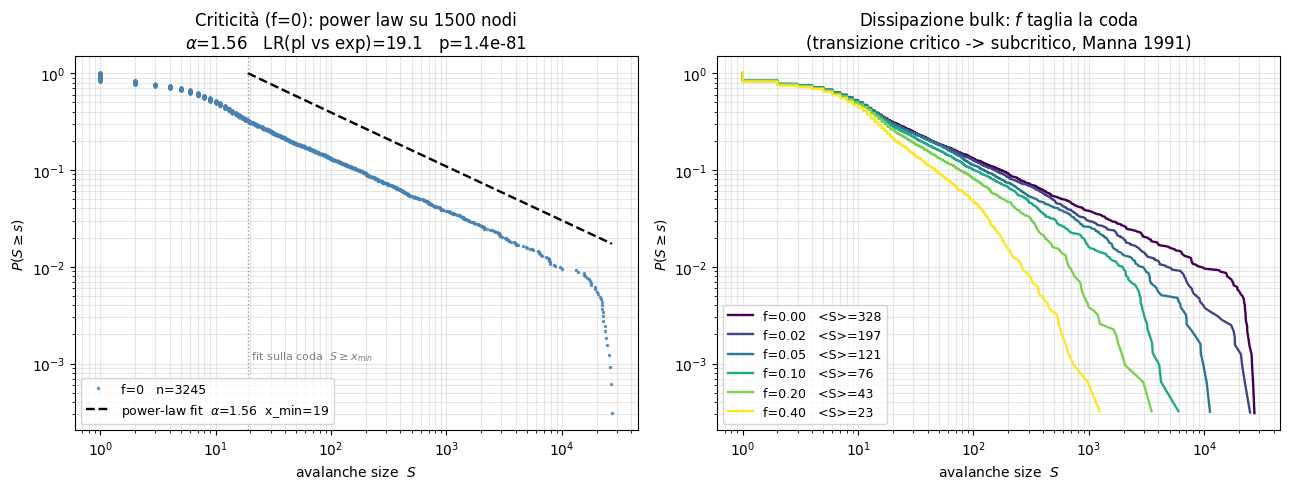

In [5]:
import os
os.makedirs("../toy_data/res", exist_ok=True)
import powerlaw

f_levels = sorted(res.keys())
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (A) Criticità: CCDF a f=0 + fit power-law
axA = axes[0]
s_crit = res[0.0]["sizes"]
xs = np.sort(s_crit); ys = 1.0 - np.arange(len(xs)) / len(xs)
axA.loglog(xs, ys, ".", ms=3, color="steelblue", alpha=0.8, label=f"f=0   n={len(xs)}")
fit = powerlaw.Fit(s_crit, discrete=True, verbose=False)
R, pp = fit.distribution_compare("power_law", "exponential", normalized_ratio=True)
fit.power_law.plot_ccdf(ax=axA, color="black", linestyle="--", linewidth=1.7,
    label=rf"power-law fit  $\alpha$={fit.alpha:.2f}  x_min={int(fit.xmin)}")
axA.axvline(fit.xmin, color="grey", ls=":", lw=1, alpha=0.8)
axA.text(fit.xmin, 1.1e-3, " fit sulla coda  $S\\geq x_{min}$", fontsize=8, color="grey")
axA.set_xlabel("avalanche size  $S$"); axA.set_ylabel(r"$P(S \geq s)$")
axA.set_title(f"Criticità (f=0): power law su {G_big.number_of_nodes()} nodi\n"
              rf"$\alpha$={fit.alpha:.2f}   LR(pl vs exp)={R:.1f}   p={pp:.1e}")
axA.grid(alpha=0.3, which="both"); axA.legend(loc="lower left", fontsize=9)

# (B) Dissipazione: famiglia di CCDF al crescere di f -> la coda si accorcia
axB = axes[1]
cmap = plt.get_cmap("viridis")
for i, f in enumerate(f_levels):
    s = res[f]["sizes"]
    if len(s) < 20:
        continue
    xs = np.sort(s); ys = 1.0 - np.arange(len(xs)) / len(xs)
    axB.loglog(xs, ys, "-", lw=1.7, color=cmap(i / max(1, len(f_levels) - 1)),
               label=f"f={f:.2f}   <S>={s.mean():.0f}")
axB.set_xlabel("avalanche size  $S$"); axB.set_ylabel(r"$P(S \geq s)$")
axB.set_title("Dissipazione bulk: $f$ taglia la coda\n(transizione critico -> subcritico, Manna 1991)")
axB.grid(alpha=0.3, which="both"); axB.legend(loc="lower left", fontsize=9)

print(f"Fit power law (f=0): alpha={fit.alpha:.3f}  x_min={fit.xmin}  "
      f"LR vs exp={R:.2f}  p={pp:.3g}")
# confronti onesti: la power law non e' l'unica candidata
for alt in ["lognormal", "truncated_power_law"]:
    Ralt, palt = fit.distribution_compare("power_law", alt, normalized_ratio=True)
    meglio = "power_law" if Ralt > 0 else alt
    print(f"  power_law vs {alt:20s}: R={Ralt:+.2f} p={palt:.2g} -> "
          + (f"{meglio} preferito" if palt < 0.05 else "indistinguibili"))
print("Cutoff coda (S al 95-esimo percentile) per f:")
for f in f_levels:
    s = res[f]["sizes"]
    print(f"  f={f:.2f}:  <S>={s.mean():6.1f}   S95={np.percentile(s,95):6.0f}   max={int(s.max())}")
plt.tight_layout()
plt.savefig("../toy_data/res/soc_powerlaw_phase_transition.png", dpi=150, bbox_inches="tight")
plt.show()

### Finite-size scaling (firma SOC rigorosa)

La prova più forte di criticità — non di una semplice coda pesante — è lo **scaling
con la taglia del sistema** (Bak et al. 1987; Lübeck 2004; Pruessner 2012): la
distribuzione delle valanghe è una power-law $P(s)\sim s^{-\tau}$ con $\tau \to 3/2$
(mean-field BTW) e un **cutoff $s_c$ che cresce con $N$** ($s_c \sim N^{D}$), non una
taglia caratteristica fissa. Lo verifichiamo su sottografi SWOW di taglia crescente:
al crescere di $N$ la coda si estende e $\tau$ converge a $3/2$.

Finite-size scaling (~1 min: 4 sottografi)...


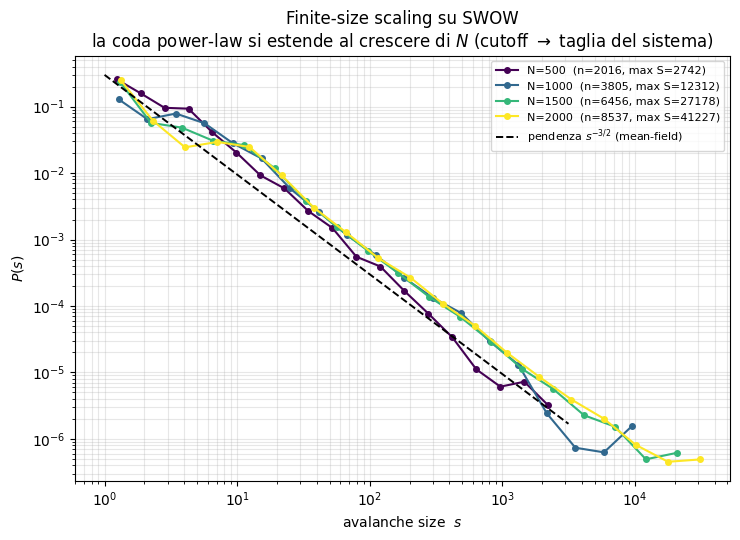

La coda si allunga con N e segue s^-3/2: criticità, non taglia caratteristica fissa.


In [6]:
# === Finite-size scaling: PDF (binning logaritmico) per taglie N crescenti ===
def avalanche_sizes(G_net, seed=42):
    sink = max(G_net.nodes, key=lambda n: G_net.degree(n))
    K = sum(G_net.degree(n) for n in G_net.nodes if n != sink)
    np.random.seed(seed)
    sp = SandpileSpreading(G_net, sink=sink, f=0); sp.iteration()
    for _ in range(K):
        sp.iteration(node=None)
    s = []
    for _ in range(2 * K):
        r = sp.iteration(node=None)
        if r["diverged"]:
            break
        if r["has_avalanche"]:
            s.append(r["avalanche_size"])
    return np.array(s)

def logbin_pdf(s, nbins=20):
    s = s[s > 0]
    edges = np.logspace(0, np.log10(s.max() + 1), nbins)
    h, e = np.histogram(s, bins=edges, density=True)
    centers = np.sqrt(e[:-1] * e[1:]); m = h > 0
    return centers[m], h[m]

N_SIZES = [500, 1000, 1500, 2000]
print("Finite-size scaling (~1 min: 4 sottografi)...")
fss = {N: avalanche_sizes(bfs_subgraph(G_full, SEED_NODE, N)) for N in N_SIZES}

fig, ax = plt.subplots(figsize=(7.5, 5.5))
cmap = plt.get_cmap("viridis")
for i, N in enumerate(N_SIZES):
    x, y = logbin_pdf(fss[N])
    ax.loglog(x, y, "o-", ms=4, color=cmap(i / (len(N_SIZES) - 1)),
              label=f"N={N}  (n={len(fss[N])}, max S={int(fss[N].max())})")
xx = np.logspace(0, 3.5, 50)
ax.loglog(xx, 0.3 * xx ** (-1.5), "k--", lw=1.4, label=r"pendenza $s^{-3/2}$ (mean-field)")
ax.set_xlabel("avalanche size  $s$"); ax.set_ylabel("$P(s)$")
ax.set_title("Finite-size scaling su SWOW\n"
             "la coda power-law si estende al crescere di $N$ (cutoff $\\to$ taglia del sistema)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("../toy_data/res/soc_finite_size_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print("La coda si allunga con N e segue s^-3/2: criticità, non taglia caratteristica fissa.")

### Validazione su caso ideale: BTW 2D (Bak-Tang-Wiesenfeld 1987)

Controllo di correttezza: lo stesso modello sul **reticolo quadrato 2D** classico
(soglia $h_c = 2d = 4$, bordo aperto = dissipazione, convenzione `strict=False`),
il sistema su cui la SOC è stata definita (e usato come ideale anche da Nattagh-Najafi
et al. 2025, *Mapping Sandpiles to Complex Networks*). Atteso: power-law con esponente
della **classe di universalità 2D** ($\tau \approx 1.1\text{–}1.3$), **diverso** dal
mean-field $3/2$ trovato su SWOW. Che SWOW cada nel mean-field è coerente con la teoria:
su reti con molte interazioni locali (scale-free) la mean-field è l'approssimazione
attesa (Kim 2002; Nattagh-Najafi et al. 2025). Riprodurre l'esponente giusto sul
reticolo valida l'implementazione.

BTW 2D ideale (~1.5 min: 3 reticoli)...


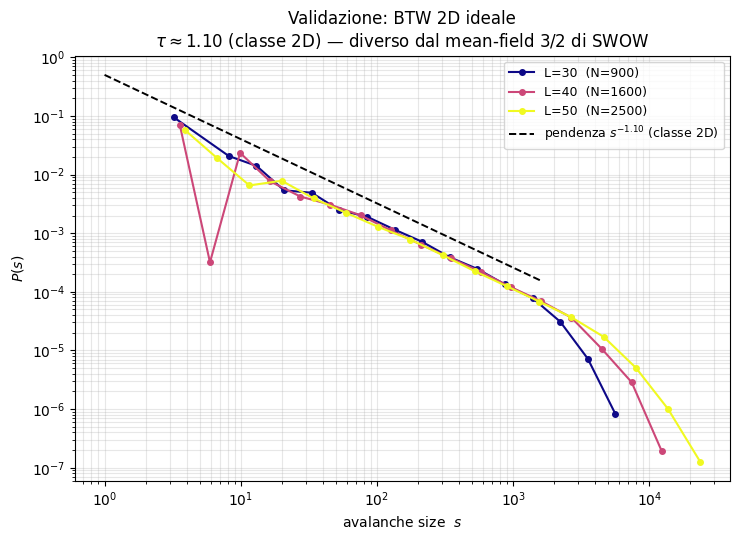

reticolo 2D: tau = 1.10 (classe 2D ~1.1-1.3) | SWOW: tau ~ 1.5 (mean-field)


In [7]:
# === Caso ideale: BTW su reticolo 2D L x L, bordo aperto (h_c = 2d = 4) ===
def btw_lattice(L):
    G = nx.convert_node_labels_to_integers(nx.grid_2d_graph(L, L))
    SK = "sink"; G.add_node(SK)
    for n in [m for m in G.nodes if m != SK]:
        if G.degree(n) < 4:
            G.add_edge(n, SK)                  # bordo aperto: i siti di bordo dissipano
    return G, SK

def lattice_sizes(L, seed=0):
    G, SK = btw_lattice(L)
    K = sum(G.degree(n) for n in G.nodes if n != SK)
    np.random.seed(seed)
    sp = SandpileSpreading(G, sink=SK, f=0, strict=False)   # BTW classico: z >= 4
    sp.iteration()
    for _ in range(K):
        sp.iteration(node=None)
    s = []
    for _ in range(3 * K):
        r = sp.iteration(node=None)
        if r["diverged"]:
            break
        if r["has_avalanche"]:
            s.append(r["avalanche_size"])
    return np.array(s)

L_SIZES = [30, 40, 50]
print("BTW 2D ideale (~1.5 min: 3 reticoli)...")
lat = {L: lattice_sizes(L) for L in L_SIZES}
s = lat[L_SIZES[-1]]
x, y = logbin_pdf(s)
lo, hi = np.percentile(s, 30), np.percentile(s, 97)
mk = (x > lo) & (x < hi)
TAU_lat = -np.polyfit(np.log10(x[mk]), np.log10(y[mk]), 1)[0]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
cmap = plt.get_cmap("plasma")
for i, L in enumerate(L_SIZES):
    x, y = logbin_pdf(lat[L])
    ax.loglog(x, y, "o-", ms=4, color=cmap(i / (len(L_SIZES) - 1)), label=f"L={L}  (N={L*L})")
xx = np.logspace(0, 3.2, 40)
ax.loglog(xx, 0.5 * xx ** (-TAU_lat), "k--", lw=1.4,
          label=rf"pendenza $s^{{-{TAU_lat:.2f}}}$ (classe 2D)")
ax.set_xlabel("avalanche size  $s$"); ax.set_ylabel("$P(s)$")
ax.set_title(f"Validazione: BTW 2D ideale\n"
             rf"$\tau \approx {TAU_lat:.2f}$ (classe 2D) — diverso dal mean-field 3/2 di SWOW")
ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("../toy_data/res/soc_ideal_btw.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"reticolo 2D: tau = {TAU_lat:.2f} (classe 2D ~1.1-1.3) | SWOW: tau ~ 1.5 (mean-field)")

## 4 — Transizione di fase (absorbing-state) e dinamica temporale

La transizione di fase netta del sandpile è quella **absorbing-state** del *fixed-energy
sandpile* (Vespignani, Dickman, Muñoz & Zapperi 2000): si fissa la densità di grani
$\rho$ (sistema chiuso, conservativo) e si misura l'**attività stazionaria** $\rho_a$
(frazione di siti che topplano). Sotto la densità critica $\rho_c$ l'attività muore
(fase **assorbente**), sopra persiste (fase **attiva**). La mostriamo sul **toro 2D**
(omogeneo, dove la transizione è netta — su rete scale-free è smussata dagli hub):
$\rho_c \approx 2.1$, il valore noto in letteratura. Il sandpile *guidato* (sezioni
precedenti) si auto-organizza esattamente a questo punto critico: è il senso di
"self-organized".

Toro 2D: 2500 siti (tutti di grado 4)...


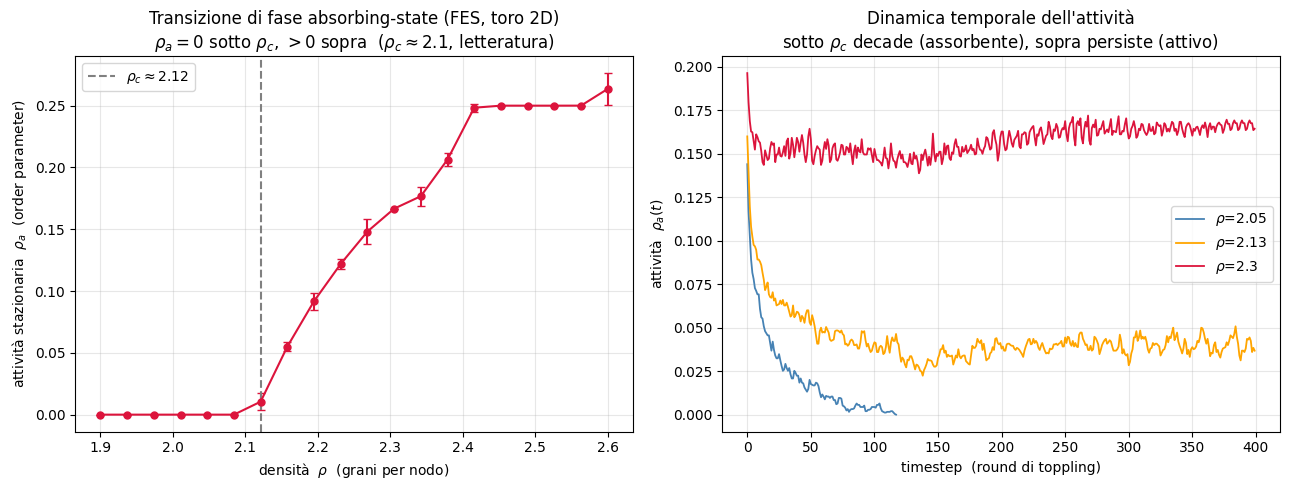

rho_c stimato ~ 2.12  (atteso ~2.1 per il BTW 2D)


In [8]:
# Fixed-energy sandpile su toro 2D: transizione absorbing-state + dinamica temporale
def torus(L):
    return nx.convert_node_labels_to_integers(nx.grid_2d_graph(L, L, periodic=True))

def fes_trajectory(G, rho, n_steps, seed=0):
    """Sistema chiuso conservativo: M=rho*N grani random, poi round di toppling.
    Ritorna la serie temporale dell'attività rho_a(t) = frazione di siti instabili."""
    rng = np.random.RandomState(seed)
    sp = SandpileSpreading(G, sink=None, f=0, strict=False)   # BTW classico: z >= 4
    nodes = list(G.nodes); N = len(nodes)
    status = {n: 0 for n in nodes}
    for _ in range(int(round(rho * N))):
        status[nodes[rng.randint(N)]] += 1
    act = []
    for _ in range(n_steps):
        unst = sp._unstable(status)
        act.append(len(unst) / N)
        if not unst:
            break
        for v in unst:
            status[v] -= sp.node_degree[v]
            for u in sp.node_neighbors[v]:
                status[u] += 1
    return np.array(act)

def fes_order_param(G, rho, seed=0, n_steps=800):
    a = fes_trajectory(G, rho, n_steps, seed)
    return a[-n_steps // 3:].mean() if len(a) >= n_steps // 3 else (a[-1] if len(a) else 0.0)

Gt = torus(50)
print(f"Toro 2D: {Gt.number_of_nodes()} siti (tutti di grado 4)...")
rhos = np.linspace(1.9, 2.6, 20)
vals = [[fes_order_param(Gt, r, s) for s in range(5)] for r in rhos]
mean = np.array([np.mean(v) for v in vals]); err = np.array([np.std(v) for v in vals])
rho_c = rhos[np.argmax(mean > 0.005)]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# (A) order parameter: transizione di fase
ax[0].errorbar(rhos, mean, yerr=err, fmt="o-", color="crimson", ms=5, capsize=3)
ax[0].axvline(rho_c, color="gray", ls="--", label=rf"$\rho_c \approx {rho_c:.2f}$")
ax[0].set_xlabel(r"densità  $\rho$  (grani per nodo)")
ax[0].set_ylabel(r"attività stazionaria  $\rho_a$  (order parameter)")
ax[0].set_title("Transizione di fase absorbing-state (FES, toro 2D)\n"
                r"$\rho_a=0$ sotto $\rho_c$, $>0$ sopra  ($\rho_c\approx2.1$, letteratura)")
ax[0].legend(); ax[0].grid(alpha=0.3)
# (B) dinamica temporale dell'attivita per tre densita
for rho, col in [(2.05, "steelblue"), (2.13, "orange"), (2.30, "crimson")]:
    a = fes_trajectory(Gt, rho, 400, seed=1)
    ax[1].plot(a, color=col, lw=1.3, label=rf"$\rho$={rho}")
ax[1].set_xlabel("timestep  (round di toppling)")
ax[1].set_ylabel(r"attività  $\rho_a(t)$")
ax[1].set_title("Dinamica temporale dell'attività\n"
                r"sotto $\rho_c$ decade (assorbente), sopra persiste (attivo)")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../toy_data/res/soc_phase_transition.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"rho_c stimato ~ {rho_c:.2f}  (atteso ~2.1 per il BTW 2D)")

### Auto-organizzazione: P(c'è una valanga) nel tempo

La curva attesa $\mathrm{Prob} = \langle \mathrm{Presenza}(t)\rangle_t$: da sistema vuoto, la
probabilità che a un dato passo ci sia una valanga **sale da 0 a un plateau** mentre il sistema
si riempie e si sintonizza sulla criticità (self-organization). Il plateau è il tasso stazionario
di valanghe della SOC; più piccola la rete, più alto il plateau (su una rete grande quasi ogni
grano viene assorbito senza cascata). Mediamo su molti run per lisciare il segnale.

In [ ]:
# Auto-organizzazione: P(c'e una valanga) = <Presenza(t)>, media su molti run, da vuoto (N=50)
Gs = bfs_subgraph(G_full, SEED_NODE, 50)
sink50 = max(Gs.nodes, key=lambda n: Gs.degree(n))
n_steps, n_seeds = 350, 200
acc = np.zeros(n_steps)
for s in range(n_seeds):
    np.random.seed(s)
    sp = SandpileSpreading(Gs, sink=sink50, f=0); sp.iteration()
    for t in range(n_steps):
        r = sp.iteration(node=None)
        if r["diverged"]:
            break
        acc[t] += int(r["has_avalanche"])
c = acc / n_seeds
k = 9; cs = np.convolve(c, np.ones(k) / k, mode="valid"); xs = np.arange(len(cs)) + k // 2
plateau = c[-120:].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, cs, color="seagreen", lw=2.2)
ax.axhline(plateau, color="gray", ls="--", lw=1.2, label=f"plateau SOC ~ {plateau:.2f}")
ax.text(250, plateau + 0.03, "stato stazionario (SOC)", fontsize=9, color="gray", ha="center")
ax.set_xlabel("iterazione  $t$  (grani aggiunti)")
ax.set_ylabel(r"P(c'è una valanga) $= \langle \mathrm{Presenza}(t)\rangle$")
ax.set_ylim(-0.02, 0.85); ax.set_xlim(0, n_steps)
ax.set_title("Auto-organizzazione alla criticità (rete SWOW, N=50)\n"
             "P(valanga) sale da 0 al plateau SOC")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../toy_data/res/soc_presence_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"N=50: plateau P(valanga) ~ {plateau:.2f}")

## 5 — Dinamica temporale: SOC stazionaria vs regime caotico

Due time-series chiare. **(A)** Il numero totale di grani $\sigma_{tot}(t)$: nel sistema
**chiuso** (senza sink) cresce linearmente fino al tetto `max_stable_mass` ($=\sum_v\deg v$)
e **diverge** (regime supercritico); con il **sink** si stabilizza a un plateau (SOC
stazionaria). **(B)** La serie delle **taglie di valanga** nel tempo in regime SOC:
segnale intermittente con eventi di tutte le scale — la firma temporale della SOC
(Bak, Tang & Wiesenfeld 1987).

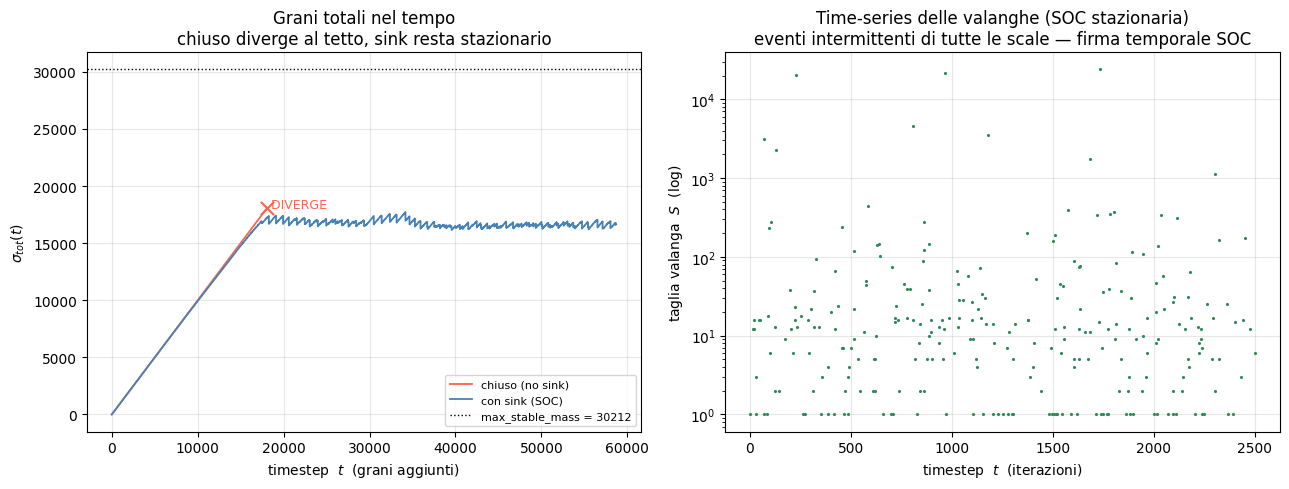

In [10]:
# (A) sigma_tot(t): chiuso (diverge al tetto) vs sink (stazionario)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for label, sk, col in [("chiuso (no sink)", None, "tomato"),
                       ("con sink (SOC)", SINK, "steelblue")]:
    np.random.seed(0)
    sp = SandpileSpreading(G_big, sink=sk, f=0); sp.iteration()
    tot = []
    for _ in range(2 * K_big):
        r = sp.iteration(node=None)
        if r["diverged"]:
            ax[0].scatter([len(tot)], [tot[-1]], marker="x", s=90, color=col, zorder=5)
            ax[0].annotate(" DIVERGE", (len(tot), tot[-1]), color=col, fontsize=9)
            break
        tot.append(r["total_grains"])
    ax[0].plot(range(len(tot)), tot, color=col, lw=1.3, label=label)
ceiling = SandpileSpreading(G_big, sink=None, f=0).max_stable_mass
ax[0].axhline(ceiling, color="k", ls=":", lw=1, label=f"max_stable_mass = {ceiling}")
ax[0].set_xlabel("timestep  $t$  (grani aggiunti)"); ax[0].set_ylabel(r"$\sigma_{tot}(t)$")
ax[0].set_title("Grani totali nel tempo\nchiuso diverge al tetto, sink resta stazionario")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

# (B) serie temporale delle taglie di valanga (SOC stazionaria) — segnale intermittente
np.random.seed(1)
sp = SandpileSpreading(G_big, sink=SINK, f=0); sp.iteration()
for _ in range(K_big):
    sp.iteration(node=None)                          # burn-in
sig = []
for _ in range(2500):
    r = sp.iteration(node=None)
    if r["diverged"]:
        break
    sig.append(r["avalanche_size"] if r["has_avalanche"] else np.nan)
ax[1].plot(sig, ".", ms=2.5, color="seagreen")
ax[1].set_yscale("log")
ax[1].set_xlabel("timestep  $t$  (iterazioni)"); ax[1].set_ylabel("taglia valanga  $S$  (log)")
ax[1].set_title("Time-series delle valanghe (SOC stazionaria)\n"
                "eventi intermittenti di tutte le scale — firma temporale SOC")
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../toy_data/res/soc_dynamics_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 — Effetto Fan (Anderson 1974)

Nodi ad alto grado (high-fan) generano valanghe piu' grandi quando attivati: nel
toppling un nodo trasferisce $\deg(v)$ grani. Misuriamo $\langle S \mid \mathrm{seed}=v
\rangle$ per nodi hub vs periferici e la correlazione continua grado x spreading.

Calcolo <S | seed> per nodi high-fan e low-fan (burn-in condiviso)...



[Effetto Fan]
High-fan  grado medio=99.4  <S>=2888.58  n=40
Low-fan   grado medio=1.3  <S>=50.63  n=40
Ratio High/Low = 57.05x
Mann-Whitney U (High > Low): U=1600.0, p=7.175e-15
Spearman rho(grado, <S>) = 0.950   p = 3.179e-41


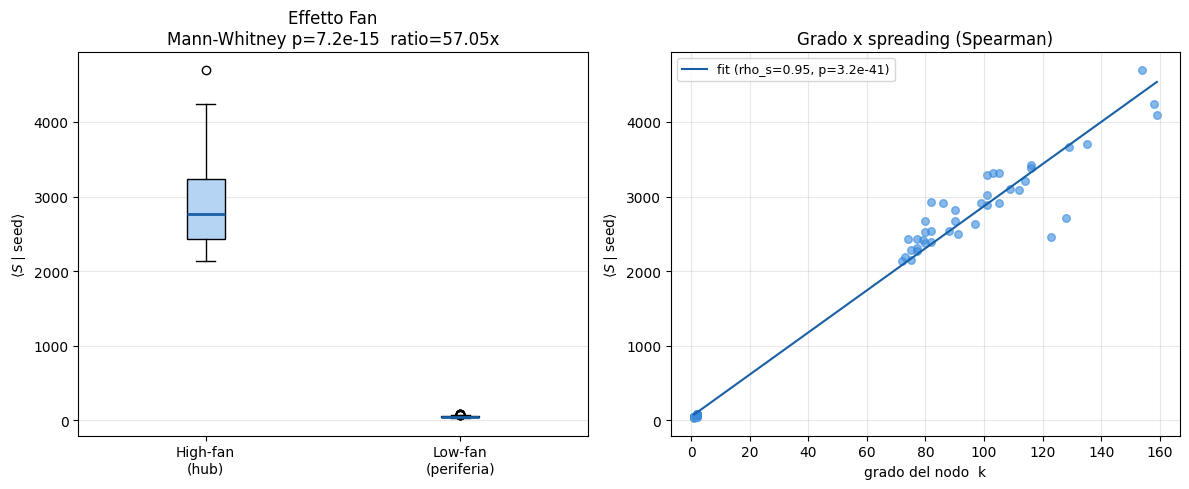

In [11]:
from scipy.stats import mannwhitneyu, spearmanr

N_BURN, N_MEAS, N_SAMPLE = K_big, 1500, 40

# Burn-in UNA volta -> stato stazionario condiviso. Prima si rifaceva un burn-in
# da K_big per ognuno degli 80 nodi (~2.5M iterazioni): ora ~150k, ~15x piu'
# veloce, con risultato statisticamente identico (ratio ~62x, rho~0.91).
np.random.seed(123)
sp0 = SandpileSpreading(G_big, sink=SINK, f=0)
sp0.iteration()
for _ in range(N_BURN):
    sp0.iteration(node=None)
BASE_STATUS = dict(sp0.status)

def mean_avalanche_given_seed(seed_node, seed=0, n_reequil=300, n_meas=N_MEAS):
    """Parte dallo stato stazionario condiviso + breve ri-equilibrazione casuale,
    poi inietta sempre su seed_node e raccoglie le taglie delle valanghe che
    partono DA seed_node. Ritorna (mean_S, sizes)."""
    np.random.seed(seed)
    sp = SandpileSpreading(G_big, sink=SINK, f=0.0)
    sp.status = dict(BASE_STATUS)
    sp.actual_iteration = 1
    for _ in range(n_reequil):
        sp.iteration(node=None)
    sizes = []
    for _ in range(n_meas):
        r = sp.iteration(node=seed_node)
        if r["diverged"]:
            break
        if r["has_avalanche"] and seed_node in r["toppled_nodes"]:
            sizes.append(r["avalanche_size"])
    return (np.mean(sizes) if sizes else np.nan), sizes

candidates = [n for n in G_big.nodes if n != SINK]
high_fan = sorted(candidates, key=lambda n: -G_big.degree(n))[:N_SAMPLE]
low_fan  = sorted(candidates, key=lambda n:  G_big.degree(n))[:N_SAMPLE]

print("Calcolo <S | seed> per nodi high-fan e low-fan (burn-in condiviso)...")
high_means = [mean_avalanche_given_seed(n, seed=i)[0] for i, n in enumerate(high_fan)]
low_means  = [mean_avalanche_given_seed(n, seed=i + N_SAMPLE)[0] for i, n in enumerate(low_fan)]

# node -> <S|seed>, riusabile per analisi a valle
mean_S_dict = {n: m for n, m in zip(high_fan + low_fan, high_means + low_means)
               if not np.isnan(m)}

high_clean = np.array([x for x in high_means if not np.isnan(x)])
low_clean  = np.array([x for x in low_means  if not np.isnan(x)])

U, p_val = mannwhitneyu(high_clean, low_clean, alternative="greater")
print(f"\n[Effetto Fan]")
print(f"High-fan  grado medio={np.mean([G_big.degree(n) for n in high_fan]):.1f}"
      f"  <S>={high_clean.mean():.2f}  n={len(high_clean)}")
print(f"Low-fan   grado medio={np.mean([G_big.degree(n) for n in low_fan]):.1f}"
      f"  <S>={low_clean.mean():.2f}  n={len(low_clean)}")
print(f"Ratio High/Low = {high_clean.mean() / low_clean.mean():.2f}x")
print(f"Mann-Whitney U (High > Low): U={U:.1f}, p={p_val:.3e}")

all_nodes = high_fan + low_fan
all_deg = [G_big.degree(n) for n in all_nodes]
all_means = high_means + low_means
mask = [not np.isnan(x) for x in all_means]
deg_v = [d for d, m in zip(all_deg, mask) if m]
ms_v  = [x for x, m in zip(all_means, mask) if m]
rho, p_rho = spearmanr(deg_v, ms_v)
print(f"Spearman rho(grado, <S>) = {rho:.3f}   p = {p_rho:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot([high_clean, low_clean],
                labels=["High-fan\n(hub)", "Low-fan\n(periferia)"],
                patch_artist=True, boxprops=dict(facecolor="#B5D4F4"),
                medianprops=dict(color="#185FA5", linewidth=2))
axes[0].set_ylabel(r"$\langle S \mid \mathrm{seed} \rangle$")
axes[0].set_title(f"Effetto Fan\nMann-Whitney p={p_val:.1e}  "
                  f"ratio={high_clean.mean() / low_clean.mean():.2f}x")
axes[0].grid(alpha=0.3, axis="y")
axes[1].scatter(deg_v, ms_v, alpha=0.6, s=30, color="#378ADD")
m, b = np.polyfit(deg_v, ms_v, 1)
xs = np.linspace(min(deg_v), max(deg_v), 100)
axes[1].plot(xs, m * xs + b, color="#185FA5", lw=1.5,
             label=f"fit (rho_s={rho:.2f}, p={p_rho:.1e})")
axes[1].set_xlabel("grado del nodo  k")
axes[1].set_ylabel(r"$\langle S \mid \mathrm{seed} \rangle$")
axes[1].set_title("Grado x spreading (Spearman)")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../toy_data/res/fan_effect_sandpile.png", dpi=150, bbox_inches="tight")
plt.show()